# 01 — Exploratory Data Analysis

Loads the raw eye-tracking recordings, applies the data-quality exclusion criteria, splits off the held-out test set, and produces the descriptive/illustrative plots (gaze heatmaps, raw time series, fixation/saccade overlays) that appear in the manuscript.

Part of the pipeline: **01 (this notebook) → 02 feature creation → 03 feature analysis → 04 model training → 05 model testing**. `06_extra_analyses.ipynb` covers everything outside this main line (MoCA/UPDRS, BIC-vs-exhaustive-search).


In [1]:
# Utilities
import os
import random
import pickle
from itertools import combinations

# Data management
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
%matplotlib inline

# Custom utilities
from futils import (
    read_patient_files,
    get_crosscorr_lags,
    get_blink_metrics,
    normalize_column,
)


In [2]:
global_random_state = 42

# Only change to True the ones you want to actually run -- everything else
# reuses the pkls already produced by a prior full run.
run_raw_data_load = False       # re-read raw .dat files instead of ../pkls/basic/patient_data.pkl -- takes a few minutes
run_problematic_checks = False  # recompute exclusion criteria instead of loading the cached result -- takes about 30 min


## Read in the raw data

In [3]:
#######################################################################
# File that contains mapping to young control, age-matched control and PD groups
group_labels = pd.read_excel("../extra_files/RESUMEN HF+HG.xlsx")[['CODIGO', 'TIPO']]
group_labels = group_labels.dropna(how='all')  # There are some fully empty rows
group_labels['group'] = group_labels['TIPO'].str.strip()  # Removing trailing spaces
group_labels['group'] = group_labels['group'].apply(lambda x: "PD" if "parkinson" in x.lower() else x)
group_labels['group_general'] = group_labels['group'].apply(lambda x: "control" if "control" in x.lower() else "PD")
group_labels['group'] = group_labels['group'].apply(lambda x: "young control" if x == "control joven" else x)
group_labels = group_labels.rename(columns={'CODIGO': 'patient_id'})

# There is one patient with MSA diagnosis, should not be taken into account:
group_labels = group_labels[group_labels['TIPO'] != "MSA"]

# A row needs to be added manually because this patient has other observations
new_row_34 = {'patient_id': 'HG034_V1', 'TIPO': 'PD', 'TIPO_GENERAL': 'PD'}
new_row_38 = {'patient_id': 'HG038V1', 'TIPO': 'PD', 'TIPO_GENERAL': 'PD'}
group_labels = pd.concat([group_labels, pd.DataFrame([new_row_34]), pd.DataFrame([new_row_38])], ignore_index=True)

# remove variables 'TIPO' and 'TIPO_GENERAL' because they are not needed
group_labels = group_labels.drop(columns=['TIPO', 'TIPO_GENERAL'])

#######################################################################
# Files that contain the visual exploration data

# Set the directory where the measurements are found. It has the next example structure:
# (...)/[HF|HGJ][]/Exploration_[1-6]/
data_dir = "../../../media/4_Exploration/E_Original_Data_Mayo2024/Data_Out/"

# Where:
    # HF|HGJ represents the hospital where the measurement was taken
    # The number afterwards is usually comprised by 3 digits and refers to the patiens
    # There are 6 exploration tries

# And each of the explorations would have the next 5 files:
# LEvent.dat LTS.dat REvent.dat RTS.dat target.dat

# Where:
    # L refers to Left eye; R refers to right eye
    # Event is the processed data with events (saccades, fixations, etc.)
    # target contains the coordinates of the targets

# Read in the data - this creates a nested dictionary with each patients' dataframes
# So that they can be accessed via the next structure:
# example_revent = patient_data[patient_id][exploration_id]['revent']

if not run_raw_data_load:
    with open('../pkls/basic/patient_data.pkl', 'rb') as f:
        patient_data = pickle.load(f)
else:
    patient_data = read_patient_files(data_dir)

    # Remove one specific patient from the data because they are ineligible due to a medical condition
    del patient_data['HG068']


## Data Preprocessing

In [4]:
#######################################################################
## Remove problematic observations

if not run_problematic_checks:
    with open('../pkls/basic/problematic_observations.pkl', 'rb') as f:
        problematic_observations = pickle.load(f)
else:
    # Ad hoc function, see docstring for details
    blink_metrics_df = get_blink_metrics(patient_data)
    # Ad hoc function, see docstring for details
    crosscorr_lags_df = get_crosscorr_lags(patient_data)

    # Full join on 'patient_id' and 'exploration_id'
    problematic_observations = pd.merge(crosscorr_lags_df, blink_metrics_df, on=['patient_id', 'exploration_id'], how='outer')
    # Filter for problematic observations to create a list
    problematic_observations = problematic_observations[(problematic_observations['problematic_synch'] == 1) | (problematic_observations['problematic_observation'] == 1)]

# Iterate over each row in the problematic_observations DataFrame
for _, row in problematic_observations.iterrows():
    patient_id = row['patient_id']
    exploration_id = row['exploration_id']

    # Check if the patient and exploration exist in the patient_data dictionary
    if patient_id in patient_data and exploration_id in patient_data[patient_id]:
        # Safely remove specified keys if they exist
        for key in ['rts_noblinks', 'lts_noblinks', 'revent', 'levent']:
            if key in patient_data[patient_id][exploration_id]:
                del patient_data[patient_id][exploration_id][key]

        # If needed, remove the exploration itself if it's now empty
        if not patient_data[patient_id][exploration_id]:
            del patient_data[patient_id][exploration_id]


#######################################################################
## Normalise the data to be between 0 and 1 for x and 0 and ymax/xmax for y
# The values are hardcoded since we know the max and min values from the software
# This maintains the aspect ratio of the data
#
# Only runs on a fresh raw load: patient_data.pkl is always saved already
# normalized (see below), so normalizing it again on a pkl-loaded run would
# silently divide already-[0,1] coordinates by 2000 a second time.
if run_raw_data_load:
    max_min_values = {'x': {'max': 2000, 'min': 0}, 'y': {'max': 2000, 'min': 0}}

    for patient_id in patient_data.keys():
        for exploration_id in patient_data[patient_id].keys():
            for key in ['rts_noblinks', 'lts_noblinks']:
                if key in patient_data[patient_id][exploration_id]:
                    data = patient_data[patient_id][exploration_id][key]
                    data['x'] = normalize_column(data['x'], max_min_values['x']['min'], max_min_values['x']['max'])
                    data['y'] = normalize_column(data['y'], max_min_values['y']['min'], max_min_values['y']['max'])
                    patient_data[patient_id][exploration_id][key] = data


### Reviewer Response: Exclusion Counts by Cohort

Participant/observation reconciliation for a reviewer question about how many observations were excluded per cohort and whether PD vs HC exclusion rates were balanced.


In [5]:
import re
from scipy.stats import fisher_exact

all_exploration_ids = ['Exploration_1', 'Exploration_2', 'Exploration_3', 'Exploration_4', 'Exploration_5', 'Exploration_6']
patients_with_recordings = list(patient_data.keys())

# 1. Unique participants per cohort, and the total
cohort_membership = group_labels[group_labels['patient_id'].isin(patients_with_recordings)]
participants_per_cohort = cohort_membership['group'].value_counts(dropna=False)
print("1. Unique participants per cohort (participants with recordings):")
print(participants_per_cohort)
print("Total participants with recordings:", len(patients_with_recordings))

unlabelled_participants = cohort_membership[cohort_membership['group'].isna()]['patient_id'].tolist()
print("Participants with recordings but no cohort label (group is NaN):", unlabelled_participants)

base_ids = {}
for patient_id in patients_with_recordings:
    base_id = re.sub(r'(_V1|V1)$', '', patient_id)
    base_ids.setdefault(base_id, []).append(patient_id)
duplicate_id_groups = {base_id: ids for base_id, ids in base_ids.items() if len(ids) > 1}
print("Patient IDs sharing the same base ID (possible same-person double-count):", duplicate_id_groups)
print()


[output removed: contained participant-level rows. Re-run the notebook against your own copy of the recordings to regenerate it.]

In [6]:
# 2. Total observations available, and whether it equals participants x 12
remaining_observations_count = {}
for patient_id in patient_data:
    count = 0
    for exploration_id in patient_data[patient_id]:
        if 'rts_noblinks' in patient_data[patient_id][exploration_id]:
            count += 1
        if 'lts_noblinks' in patient_data[patient_id][exploration_id]:
            count += 1
    remaining_observations_count[patient_id] = count

excluded_per_patient = problematic_observations.groupby('patient_id').size()

available_before_exclusion_per_patient = {
    patient_id: remaining_observations_count.get(patient_id, 0) + int(excluded_per_patient.get(patient_id, 0))
    for patient_id in patients_with_recordings
}

total_observations_available = sum(available_before_exclusion_per_patient.values())
nominal_observations_if_all_complete = len(patients_with_recordings) * 12

print("2. Observations available:")
print("Total observations available (reconstructed, before percentile-based exclusion):", total_observations_available)
print("Nominal total if every participant had all 12 (6 explorations x 2 eyes):", nominal_observations_if_all_complete)
print("Equal?", total_observations_available == nominal_observations_if_all_complete)

participants_under_12 = {pid: n for pid, n in available_before_exclusion_per_patient.items() if n < 12}
print("Participants with fewer than 12 available observations:", len(participants_under_12))
for patient_id, n_available in participants_under_12.items():
    missing_explorations = sorted(set(all_exploration_ids) - set(patient_data[patient_id].keys()))
    print(f"  {patient_id}: {n_available} available, missing explorations entirely: {missing_explorations}")
print()


[output removed: contained participant-level rows. Re-run the notebook against your own copy of the recordings to regenerate it.]

In [7]:
# 3. Excluded observations per cohort: count and percentage of that cohort's
#    available observations
excluded_with_group = problematic_observations.merge(group_labels[['patient_id', 'group']], on='patient_id', how='left')
cohort_excluded_counts = excluded_with_group['group'].value_counts(dropna=False)

available_with_group = pd.DataFrame({
    'patient_id': list(available_before_exclusion_per_patient.keys()),
    'available_observations': list(available_before_exclusion_per_patient.values()),
}).merge(group_labels[['patient_id', 'group']], on='patient_id', how='left')
cohort_available_observations = available_with_group.groupby('group', dropna=False)['available_observations'].sum()

print("3. Excluded observations per cohort:")
for cohort in ['PD', 'control', 'young control']:
    cohort_excluded = int(cohort_excluded_counts.get(cohort, 0))
    cohort_available = int(cohort_available_observations.get(cohort, 0))
    cohort_pct_excluded = 100 * cohort_excluded / cohort_available
    print(f"  {cohort}: {cohort_excluded} excluded out of {cohort_available} available ({cohort_pct_excluded:.2f}%)")
print()

# 4. Total excluded across all cohorts
total_excluded = len(problematic_observations)
print("4. Total excluded across all cohorts:", total_excluded)
print()


3. Excluded observations per cohort:
  PD: 54 excluded out of 546 available (9.89%)
  control: 36 excluded out of 574 available (6.27%)
  young control: 1 excluded out of 251 available (0.40%)

4. Total excluded across all cohorts: 91



In [8]:
# 5. Fisher exact test on PD vs control, excluded vs retained
pd_excluded = int(cohort_excluded_counts.get('PD', 0))
pd_available = int(cohort_available_observations.get('PD', 0))
pd_retained = pd_available - pd_excluded

control_excluded = int(cohort_excluded_counts.get('control', 0))
control_available = int(cohort_available_observations.get('control', 0))
control_retained = control_available - control_excluded

contingency_table = [[pd_excluded, pd_retained], [control_excluded, control_retained]]
odds_ratio, p_value = fisher_exact(contingency_table)

print("5. PD vs control, Fisher exact test:")
print("Contingency table (rows: PD, control; columns: excluded, retained):", contingency_table)
print(f"Odds ratio: {odds_ratio:.4f}, p-value: {p_value:.4f}")
print()

# 6. Participants who lost ALL of their observations, by cohort
patients_with_no_remaining_data = [
    patient_id for patient_id in patients_with_recordings if remaining_observations_count.get(patient_id, 0) == 0
]
print("6. Participants who lost all observations:", len(patients_with_no_remaining_data))
if patients_with_no_remaining_data:
    lost_all_by_cohort = group_labels[
        group_labels['patient_id'].isin(patients_with_no_remaining_data)
    ]['group'].value_counts(dropna=False)
    print(lost_all_by_cohort)
print()


5. PD vs control, Fisher exact test:
Contingency table (rows: PD, control; columns: excluded, retained): [[54, 492], [36, 538]]
Odds ratio: 1.6402, p-value: 0.0280

6. Participants who lost all observations: 2
group
PD    2
Name: count, dtype: int64



In [9]:
# 7. Breakdown of exclusions by which criterion triggered them, per cohort.
#    The manuscript describes 3 categories; get_blink_metrics (futils.py) also
#    carries two undocumented total_events-based flags folded into the same
#    final boolean -- surfaced here separately rather than hidden.
insufficient_data_flag = (
    (excluded_with_group['pct_01_total_time_too_little_time'] > 0) |
    (excluded_with_group['pct_99_total_blinks_too_many_blinks'] > 0)
)
blink_related_flag = (
    (excluded_with_group['pct_99_pct_blinks_pct_of_blinks_vs_saccadesfixations_too_high'] > 0) |
    (excluded_with_group['pct_99_time_blinking_too_much_time_blinking'] > 0) |
    (excluded_with_group['pct_99_pct_time_blinking_pct_of_time_blinking_too_high'] > 0)
)
inter_eye_dissimilarity_flag = excluded_with_group['problematic_synch'] > 0
undocumented_total_events_flag = (
    (excluded_with_group['pct_01_total_events_too_few_events'] > 0) |
    (excluded_with_group['pct_99_total_events_too_many_events'] > 0)
)

criterion_breakdown = pd.DataFrame({
    'group': excluded_with_group['group'],
    'insufficient_data': insufficient_data_flag,
    'blink_related_data_loss': blink_related_flag,
    'inter_eye_dissimilarity': inter_eye_dissimilarity_flag,
    'undocumented_total_events_criteria': undocumented_total_events_flag,
})

print("7. Exclusions by criterion, per cohort (not mutually exclusive -- a row can trigger more than one):")
print(criterion_breakdown.groupby('group', dropna=False)[[
    'insufficient_data', 'blink_related_data_loss', 'inter_eye_dissimilarity', 'undocumented_total_events_criteria'
]].sum())
print()
paper_described_flag = insufficient_data_flag | blink_related_flag | inter_eye_dissimilarity_flag
print("Excluded rows matching the paper's stated 3-category criteria:", int(paper_described_flag.sum()))
print("Excluded rows ONLY due to the undocumented total_events criteria:", int((~paper_described_flag).sum()))


7. Exclusions by criterion, per cohort (not mutually exclusive -- a row can trigger more than one):
               insufficient_data  blink_related_data_loss  \
group                                                       
PD                            15                       12   
control                       11                       10   
young control                  0                        0   

               inter_eye_dissimilarity  undocumented_total_events_criteria  
group                                                                       
PD                                  12                                  19  
control                             10                                  15  
young control                        0                                   1  

Excluded rows matching the paper's stated 3-category criteria: 62
Excluded rows ONLY due to the undocumented total_events criteria: 29


Separating the test set at the beginning of the process. The test set is shown on the heatmaps and the statistical analyses that don't require modeling.

In [10]:
# Create the groups we will use for analyses and models

young_control_patients = group_labels[group_labels['group'] == 'young control']['patient_id'].tolist()
control_patients = group_labels[group_labels['group'] == 'control']['patient_id'].tolist()
pd_patients = group_labels[group_labels['group'] == 'PD']['patient_id'].tolist()

# Test group: sample 20% of control and 20% of PD patients, end up with a list
random.seed(42)
control_test = random.sample(control_patients, int(len(control_patients) * 0.2))
pd_test = random.sample(pd_patients, int(len(pd_patients) * 0.2))
test_patients = control_test + pd_test


In [11]:
# Define the directory where .pkl files will be saved
dir_name = '../pkls/basic/'
os.makedirs(dir_name, exist_ok=True)

with open(os.path.join(dir_name, 'patient_data.pkl'), 'wb') as f:
    pickle.dump(patient_data, f)

with open(os.path.join(dir_name, 'group_labels.pkl'), 'wb') as f:
    pickle.dump(group_labels, f)

with open(os.path.join(dir_name, 'problematic_observations.pkl'), 'wb') as f:
    pickle.dump(problematic_observations, f)


## Initial Exploration Plots

### Heatmaps


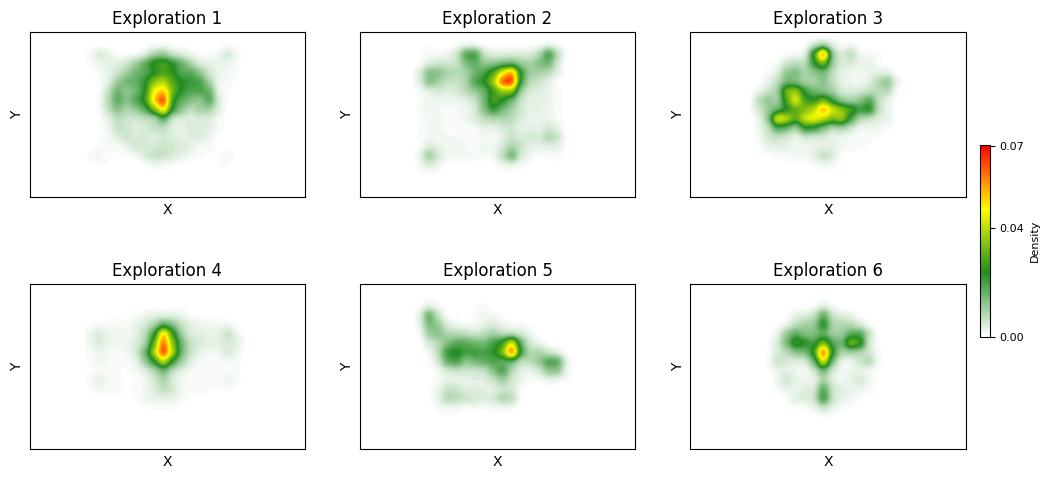

In [12]:
######################################################
### Create the overall heatmaps

################ PREPARE THE DATA FOR HEATMAPS ################

m = 30  # size of the grid

colors = [
    (1, 1, 1),            # White
    (0.13, 0.55, 0.13),   # Dark Green (Forest Green)
    (1, 1, 0),            # Yellow
    (1, 0, 0)             # Red
]
n_bins = 100
cm = LinearSegmentedColormap.from_list('white_green_red', colors, N=n_bins)

x_min_noblinks, x_max_noblinks = 0, 1
y_min_noblinks, y_max_noblinks = 0, 1

x_bins = np.linspace(x_min_noblinks, x_max_noblinks, m + 1)
y_bins = np.linspace(y_min_noblinks, y_max_noblinks, m + 1)

heatmaps = {f'Exploration_{i}': np.zeros((m, m)) for i in range(1, 7)}

for patient_folder in patient_data.keys():
    for exploration_folder in patient_data[patient_folder].keys():
        for eye in ['lts_noblinks', 'rts_noblinks']:
            if eye in patient_data[patient_folder][exploration_folder]:
                eye_data = patient_data[patient_folder][exploration_folder][eye]
                hist, _, _ = np.histogram2d(eye_data['x'], eye_data['y'], bins=[x_bins, y_bins])
                heatmaps[exploration_folder] += hist

for exploration_folder, matrix in heatmaps.items():
    total_sum = matrix.sum()
    if total_sum > 0:
        heatmaps[exploration_folder] = matrix / total_sum

################ PLOT ################

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i in range(1, 7):
    ax = axes[(i - 1) // 3, (i - 1) % 3]
    heatmap = heatmaps[f'Exploration_{i}']
    heatmap_flipped = np.flipud(heatmap.T)

    cax = ax.imshow(
        heatmap_flipped,
        interpolation='gaussian',
        cmap=cm,
        origin='lower',
        aspect='equal',
        extent=[x_min_noblinks, x_max_noblinks, y_min_noblinks, y_max_noblinks],
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0.4, 1)
    ax.set_title(f'Exploration {i}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('Y', fontsize=10)
    ax.tick_params(labelsize=8)

plt.subplots_adjust(left=0.1, right=0.90, top=0.90, bottom=0.08, wspace=0.2, hspace=0.05)

vmin, vmax = cax.get_clim()
vcenter = (vmin + vmax) / 2
cbar_ticks = [round(vmin, 2), round(vcenter, 2), round(vmax, 2)]

cbar = fig.colorbar(cax, ax=axes, orientation='vertical', fraction=0.01, pad=0.015, shrink=0.5)
cbar.set_label('Density', fontsize=8)
cbar.set_ticks(cbar_ticks)
cbar.ax.tick_params(labelsize=8)

plt.savefig("../plots/paper_figures/heatmaps_overall.png")
plt.show()
plt.close()


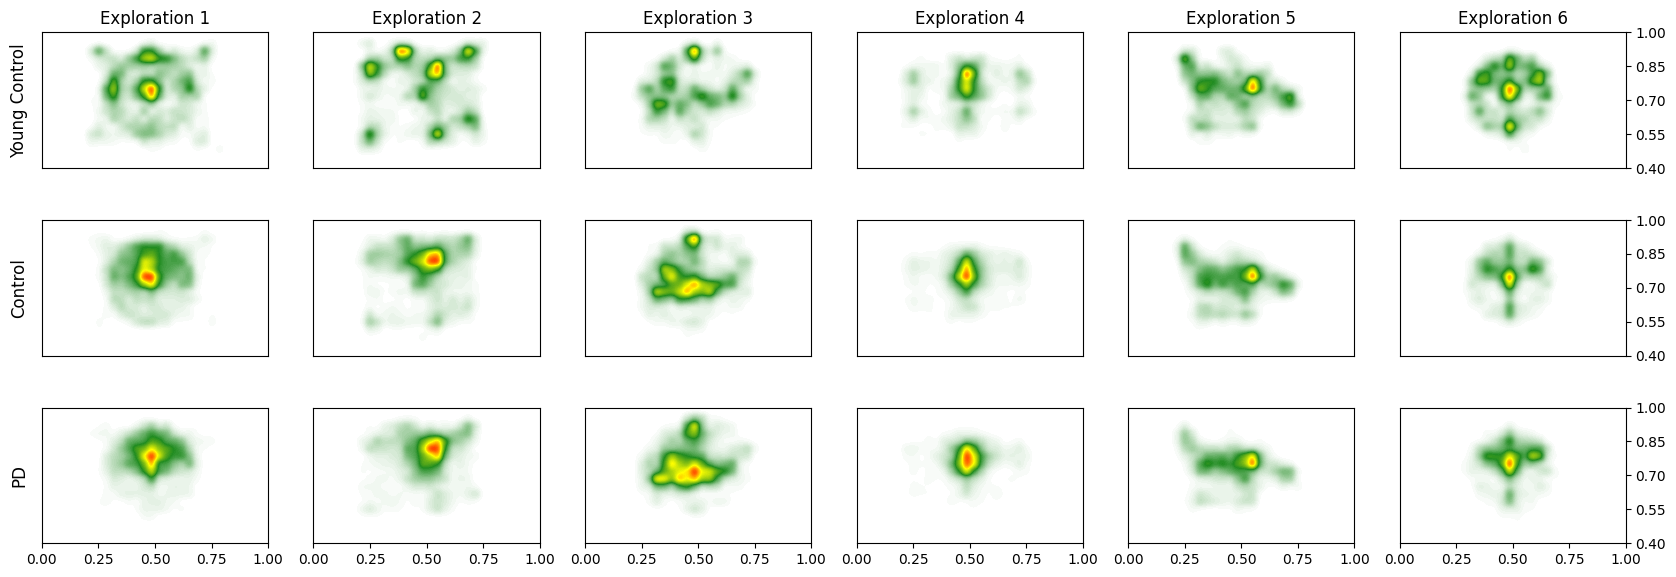

In [13]:
######################################################
### Create the group level heatmaps

################ PREPARE THE DATA FOR HEATMAPS ################
patient_types = group_labels['group'].unique()
group_heatmaps = {
    patient_type: {f'Exploration_{i}': np.zeros((m, m)) for i in range(1, 7)}
    for patient_type in patient_types
}

for patient_folder in patient_data.keys():
    patient_type = group_labels[group_labels['patient_id'] == patient_folder]['group'].values[0]
    for exploration_folder in patient_data[patient_folder].keys():
        for eye in ['lts_noblinks', 'rts_noblinks']:
            if eye in patient_data[patient_folder][exploration_folder]:
                eye_data = patient_data[patient_folder][exploration_folder][eye]
                hist, _, _ = np.histogram2d(eye_data['x'], eye_data['y'], bins=[x_bins, y_bins])
                group_heatmaps[patient_type][exploration_folder] += hist

for patient_type, explorations in group_heatmaps.items():
    for exploration_folder, matrix in explorations.items():
        total_sum = matrix.sum()
        if total_sum > 0:
            group_heatmaps[patient_type][exploration_folder] = matrix / total_sum

################ PLOT ################

fig, axes = plt.subplots(3, 6, figsize=(18, 6.5))

patient_groups = ["young control", "control", "PD"]
row_labels = ["Young Control", "Control", "PD"]

for row_idx, patient_type in enumerate(patient_groups):
    for col_idx in range(1, 7):
        ax = axes[row_idx, col_idx - 1]
        heatmap = group_heatmaps[patient_type][f'Exploration_{col_idx}']
        heatmap_flipped = np.flipud(heatmap.T)

        cax = ax.imshow(
            heatmap_flipped,
            interpolation='gaussian',
            cmap=cm,
            origin='lower',
            aspect='equal',
            extent=[x_min_noblinks, x_max_noblinks, y_min_noblinks, y_max_noblinks],
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0.4, 1)

        if col_idx == 6:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            ytick_positions = np.linspace(0.4, 1, 5)
            ax.set_yticks(ytick_positions)
            ax.set_yticklabels([f"{tick:.2f}" for tick in ytick_positions])
        else:
            ax.set_yticks([])

        if row_idx == 2:
            xtick_positions = np.linspace(0, 1, 5)
            ax.set_xticks(xtick_positions)
            ax.set_xticklabels([f"{tick:.2f}" for tick in xtick_positions])
        else:
            ax.set_xticks([])

        if col_idx == 1:
            ax.set_ylabel(row_labels[row_idx], fontsize=12, rotation=90, labelpad=10)
        if row_idx == 0:
            ax.set_title(f'Exploration {col_idx}', fontsize=12)

plt.subplots_adjust(left=0.06, right=0.94, top=0.92, bottom=0.08, wspace=0.2, hspace=0.1)
plt.savefig("../plots/paper_figures/heatmaps_grouped.png")
plt.show()
plt.close()


### Observations

Randomly selected observations for the next number of patients


In [14]:
# Randomly select 4 patients from the dataset (seed for reproducibility)
random.seed(68)
n_patients = 4
selected_patients = random.sample(list(patient_data.keys()), n_patients)
explorations_plots = [f"Exploration_{random.randint(1, 6)}" for _ in range(n_patients)]


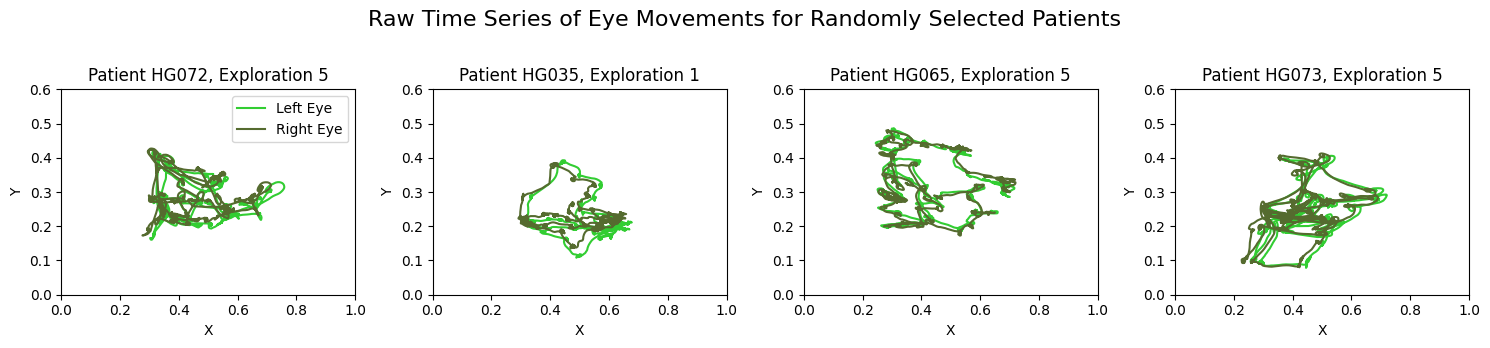

In [15]:
# Create a 1-row, 4-column plot
fig, axes = plt.subplots(1, n_patients, figsize=(15, 3.5))
fig.suptitle('Raw Time Series of Eye Movements for Randomly Selected Patients', fontsize=16)

for i in range(n_patients):
    patient_number = selected_patients[i]
    exploration_number = explorations_plots[i]

    # Limit to the first 15,000 points to avoid long running times
    lts = patient_data[patient_number][exploration_number]['lts_noblinks'].head(15000)
    rts = patient_data[patient_number][exploration_number]['rts_noblinks'].head(15000)

    axes[i].plot(lts['x'], lts['y'], label='Left Eye', color='#32CD32')
    axes[i].plot(rts['x'], rts['y'], label='Right Eye', color='#556B2F')

    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 0.6)
    axes[i].set_title(f'Patient {patient_number}, {exploration_number.replace("_", " ")}')

axes[0].legend(loc='upper right')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../plots/paper_figures/raw_time_series.png")
plt.show()
plt.close()


Randomly selected fixation and saccade events:
* For each fixation, a blob, centered in the average of all the (x,y) coordinates that appear in the time series dataframe between the start and the end time. The size of the blob will be proportional to the time spent in such fixation.
* For each saccade, a straight line that begins in the coordinate related to the start time, and ends in the coordinate related to the end time.


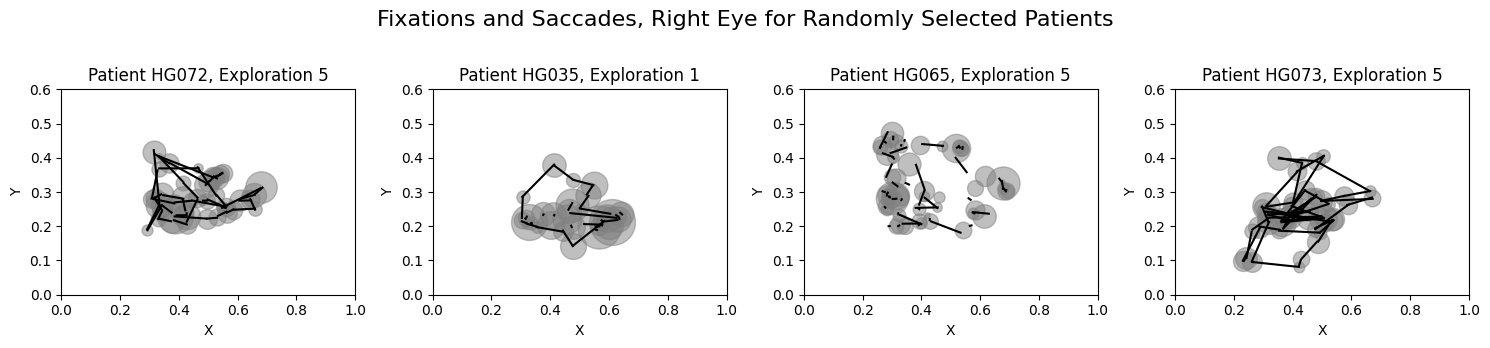

In [16]:
fig, axes = plt.subplots(1, n_patients, figsize=(15, 3.5))
fig.suptitle('Fixations and Saccades, Right Eye for Randomly Selected Patients', fontsize=16)

for i in range(n_patients):
    patient_number = selected_patients[i]
    exploration_number = explorations_plots[i]

    revent_temp = patient_data[patient_number][exploration_number]['revent']
    rts_temp = patient_data[patient_number][exploration_number]['rts_noblinks']

    fixations = []
    saccades = []

    for index, row in revent_temp.iterrows():
        start_time = row['start_time'] - 1
        end_time = row['end_time'] - 1

        if start_time < 0 or end_time >= len(rts_temp):
            continue

        if row['event'] == 'fixation':
            x_coords = rts_temp.iloc[start_time:end_time + 1]['x']
            y_coords = rts_temp.iloc[start_time:end_time + 1]['y']
            fixations.append((x_coords.mean(), y_coords.mean(), row['end_time'] - row['start_time']))
        elif row['event'] == 'saccade':
            x_0, y_0 = rts_temp.iloc[start_time][['x', 'y']]
            x_1, y_1 = rts_temp.iloc[end_time][['x', 'y']]
            saccades.append((x_0, y_0, x_1, y_1))

    ax = axes[i]
    for avg_x, avg_y, duration in fixations:
        ax.scatter(avg_x, avg_y, s=duration, c='grey', alpha=0.5)
    for x_0, y_0, x_1, y_1 in saccades:
        ax.plot([x_0, x_1], [y_0, y_1], color='black')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.6)
    axes[i].set_title(f'Patient {patient_number}, {exploration_number.replace("_", " ")}')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../plots/paper_figures/fixations_saccades.png")
plt.show()
plt.close()


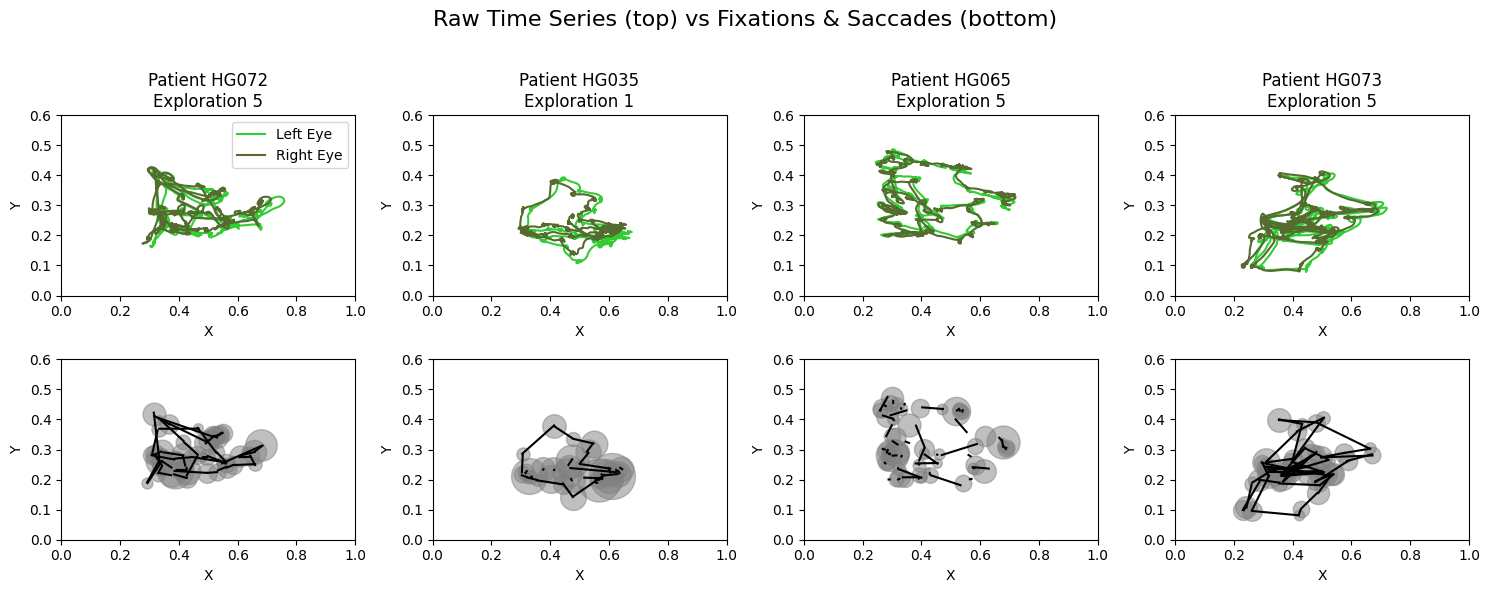

In [17]:
fig, axes = plt.subplots(2, n_patients, figsize=(15, 6), sharex=False, sharey=False)
fig.suptitle('Raw Time Series (top) vs Fixations & Saccades (bottom)', fontsize=16)

for i in range(n_patients):
    patient_number = selected_patients[i]
    exploration_name = explorations_plots[i]

    # -- Row 1: raw time series --
    ax1 = axes[0, i]
    lts = patient_data[patient_number][exploration_name]['lts_noblinks'].head(15000)
    rts = patient_data[patient_number][exploration_name]['rts_noblinks'].head(15000)
    ax1.plot(lts['x'], lts['y'], label='Left Eye', color='#32CD32')
    ax1.plot(rts['x'], rts['y'], label='Right Eye', color='#556B2F')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 0.6)
    if i == 0:
        ax1.legend(loc='upper right')
    ax1.set_title(f'Patient {patient_number}\n{exploration_name.replace("_", " ")}')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')

    # -- Row 2: fixations & saccades --
    ax2 = axes[1, i]
    revent = patient_data[patient_number][exploration_name]['revent']
    rts = patient_data[patient_number][exploration_name]['rts_noblinks']
    fixations, saccades = [], []
    for _, row in revent.iterrows():
        start, end = row['start_time'] - 1, row['end_time'] - 1
        if start < 0 or end >= len(rts):
            continue
        if row['event'] == 'fixation':
            seg = rts.iloc[start:end + 1]
            fixations.append((seg['x'].mean(), seg['y'].mean(), row['end_time'] - row['start_time']))
        else:
            x0, y0 = rts.iloc[start][['x', 'y']]
            x1, y1 = rts.iloc[end][['x', 'y']]
            saccades.append((x0, y0, x1, y1))
    for x, y, dur in fixations:
        ax2.scatter(x, y, s=dur, c='grey', alpha=0.5)
    for x0, y0, x1, y1 in saccades:
        ax2.plot([x0, x1], [y0, y1], c='black')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 0.6)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../plots/paper_figures/combined_raw_and_fixsac.png", dpi=300)
plt.show()
plt.close()


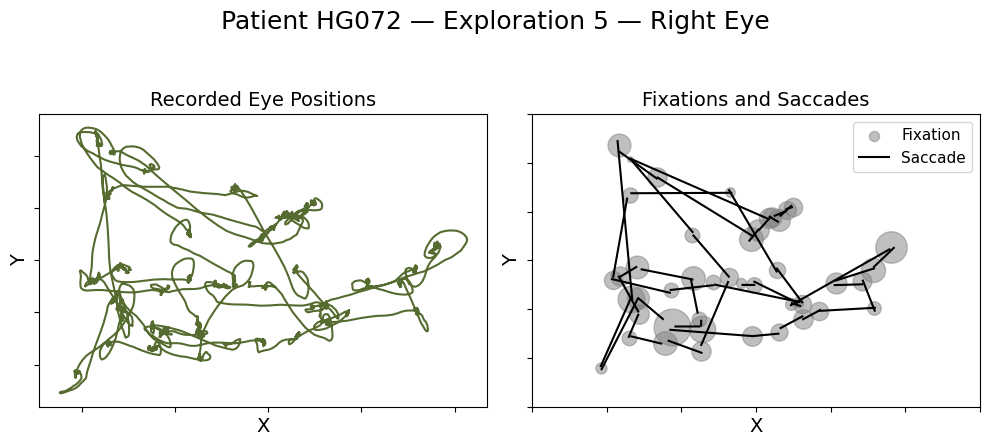

In [18]:
# Patient and exploration
patient_number = 'HG072'
exploration_name = 'Exploration_5'

rts = patient_data[patient_number][exploration_name]['rts_noblinks'].head(15000)
revent = patient_data[patient_number][exploration_name]['revent']

fig, (ax_raw, ax_fixsac) = plt.subplots(1, 2, figsize=(10, 4.5))

ax_raw.plot(rts['x'], rts['y'], color='#556B2F')
ax_raw.set_xlabel('X', fontsize=14)
ax_raw.set_ylabel('Y', fontsize=14)
ax_raw.set_title('Recorded Eye Positions', fontsize=14)
ax_raw.tick_params(labelbottom=False, labelleft=False)

fixations, saccades = [], []
for _, row in revent.iterrows():
    start, end = row['start_time'] - 1, row['end_time'] - 1
    if start < 0 or end >= len(rts):
        continue
    if row['event'] == 'fixation':
        seg = rts.iloc[start:end + 1]
        fixations.append((seg['x'].mean(), seg['y'].mean(), row['end_time'] - row['start_time']))
    else:
        x0, y0 = rts.iloc[start][['x', 'y']]
        x1, y1 = rts.iloc[end][['x', 'y']]
        saccades.append((x0, y0, x1, y1))

for x, y, dur in fixations:
    ax_fixsac.scatter(x, y, s=dur, c='grey', alpha=0.5,
                       label='Fixation' if 'Fixation' not in ax_fixsac.get_legend_handles_labels()[1] else "")
for x0, y0, x1, y1 in saccades:
    ax_fixsac.plot([x0, x1], [y0, y1], c='black',
                   label='Saccade' if 'Saccade' not in ax_fixsac.get_legend_handles_labels()[1] else "")

ax_fixsac.set_xlim(0.2, 0.8)
ax_fixsac.set_ylim(0.15, 0.45)
ax_fixsac.set_xlabel('X', fontsize=14)
ax_fixsac.set_ylabel('Y', fontsize=14)
ax_fixsac.set_title('Fixations and Saccades', fontsize=14)
ax_fixsac.tick_params(labelbottom=False, labelleft=False)
ax_fixsac.legend(loc='upper right', fontsize=11)

fig.suptitle(f'Patient {patient_number} — {exploration_name.replace("_", " ")} — Right Eye', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("../plots/paper_figures/raw_and_fixsac_HG072.png", dpi=300)
plt.show()
plt.close()
